## **Practical Python - Error Handling, Logging, and Data MAanipulation**



**Question 1:** **What is the difference between multithreading and multiprocessing?**

- Multithreading and Multiprocessing are both techniques used to achieve concurrency in a program, but they differ in how they utilize system resources and execute tasks.

   **Multithreading** is the process of executing multiple threads within a single process.
   All threads share the same memory space, which makes communication between them faster but also increases the risk of data corruption if not handled properly.
   Multithreading is best suited for **I/O-bound tasks**, such as file handling, web requests, or user interface operations.

   **Multiprocessing**, on the other hand, involves running multiple processes simultaneously, where each process has its own separate memory space.
   This avoids memory-sharing issues and allows true parallelism, especially on multi-core CPUs.
   Multiprocessing is best suited for **CPU-bound tasks**, such as data analysis, image processing, or mathematical computations.

| **Basis**              | **Multithreading**                                     | **Multiprocessing**                                            |
| ---------------------- | ------------------------------------------------------ | -------------------------------------------------------------- |
| **Definition**         | Execution of multiple threads within a single process. | Execution of multiple processes simultaneously.                |
| **Memory Usage**       | Threads share the same memory space.                   | Each process has its own memory space.                         |
| **Speed**              | Faster for I/O-bound tasks.                            | Faster for CPU-bound tasks.                                    |
| **Communication**      | Easier since threads share memory.                     | Requires inter-process communication (IPC).                    |
| **Failure Impact**     | If one thread fails, the whole process can crash.      | If one process fails, others continue running.                 |
| **Parallel Execution** | Limited by Global Interpreter Lock (GIL) in Python.    | Achieves true parallel execution.                              |
| **Example Use**        | Web browsers, servers, and GUI applications.           | Data processing, video rendering, and scientific computations. |


In [1]:
# Example: Multithreading vs Multiprocessing

import threading
import multiprocessing
import time

def task(name):
    print(f"Starting {name}")
    time.sleep(2)
    print(f"Completed {name}")

# Multithreading
start = time.time()
t1 = threading.Thread(target=task, args=("Thread-1",))
t2 = threading.Thread(target=task, args=("Thread-2",))
t1.start()
t2.start()
t1.join()
t2.join()
print("Time taken with Multithreading:", time.time() - start)

# Multiprocessing
start = time.time()
p1 = multiprocessing.Process(target=task, args=("Process-1",))
p2 = multiprocessing.Process(target=task, args=("Process-2",))
p1.start()
p2.start()
p1.join()
p2.join()
print("Time taken with Multiprocessing:", time.time() - start)


Starting Thread-1
Starting Thread-2
Completed Thread-1
Completed Thread-2
Time taken with Multithreading: 2.006242036819458
Starting Process-1
Starting Process-2
Completed Process-1
Completed Process-2
Time taken with Multiprocessing: 2.06262469291687


**Question 2: What are challenges associated with memory mangment in Python?**

- Memory management in Python refers to the process of allocating and deallocating memory to store data efficiently during program execution.
Although Python provides an automatic memory management system through its Garbage Collector and Dynamic Memory Allocation, there are still several challenges that developers may face while working with memory in Python.


  Challenges Associated with Memory Management in Python
  **a] Automatic Garbage Collection Overhead:**

  Python automatically detects and removes unused objects using Garbage Collection, but this process can sometimes cause performance overhead.
  If garbage collection occurs frequently, it may slow down the program’s execution.

  **Memory Leaks:**

   Memory leaks occur when objects that are no longer needed are not properly released from memory.
   This can happen if there are circular references or global variables holding unused objects, leading to unnecessary memory consumption.

   **Circular References:**
   A circular reference occurs when two or more objects refer to each other, preventing the Garbage Collector from freeing them.
   For example, object A references B and B references A, so neither gets deleted automatically.

  **High Memory Usage for Large Data Structures:**
   Python’s data structures (like lists, dictionaries, and objects) are flexible but memory-intensive compared to lower-level languages like C or C++.
  Handling large datasets can therefore consume more memory than expected.

   **Fragmentation of Memory:**

   Continuous creation and deletion of objects can fragment the memory space, reducing efficiency.
   Over time, this fragmentation can cause slower performance and increased memory usage.

   **Lack of Manual Control:**

   Python abstracts memory management, so programmers cannot directly allocate or deallocate memory (as in C or C++).
   This limits optimization for memory-critical applications.




In [1]:
class A:
    def __init__(self):
        self.b = None

class B:
    def __init__(self):
        self.a = None

a = A()
b = B()
a.b = b
b.a = a


Here, both objects a and b refer to each other, creating a circular reference.
Even if we delete them using del a and del b, their memory may not be released immediately, causing a memory leak until the Garbage Collector intervenes.

**Question 3: Write a Python program that logs an error message to a log file when a division by zero exception occurs.**

- In Python, the logging module is used to record messages such as errors, warnings, or informational updates while a program runs.
The following program demonstrates how to handle a division by zero exception and log the error message to a log file.

In [4]:
import logging

# Configure the logging settings
logging.basicConfig(
    filename="error_log.log",
    level=logging.ERROR,
    format="%(asctime)s - %(levelname)s - %(message)s"  # Log format
)

try:
    # Example division operation
    numerator = int(input("Enter numerator: "))
    denominator = int(input("Enter denominator: "))
    result = numerator / denominator
    print("Result:", result)

except ZeroDivisionError as e:
    print("Error: Division by zero is not allowed!")
    logging.error("Division by zero occurred: %s", e)

except Exception as e:
    print("An unexpected error occurred:", e)
    logging.error("Unexpected error: %s", e)


Enter numerator: 10
Enter denominator: 0


ERROR:root:Division by zero occurred: division by zero


Error: Division by zero is not allowed!


**Explanation:**

**Import logging module:**

It provides functions to write log messages to a file.

**basicConfig() setup:**

filename specifies the log file name.

level=logging.ERROR ensures only error messages are logged.

format defines the structure of the log entry (with timestamp and message type).

**Try–Except Block:**

The program tries to divide two numbers.

If a division by zero occurs, it prints an error message and logs the details into the file error_log.log.

**Log File Output Example (error_log.log):**

**Question 4: Write a Python program that reads from one file and writes its content to another file.**

- File handling in Python allows reading data from one file and writing it into another.
This can be done easily using the built-in open() function with appropriate file modes such as:
"r" → read mode
"w" → write mode
The following program demonstrates how to read the content from one file and copy it into another file.

In [11]:
# Open the source file in read mode
with open("source.txt", "r") as source_file:
    # Read the entire content of the source file
    content = source_file.read()

# Open the destination file in write mode
with open("destination.txt", "w") as destination_file:
    # Write the content to the new file
    destination_file.write(content)

print("File content copied successfully!")


File content copied successfully!


**Question 5: Write a program that handle both IndexError and KeyError using try-except block.**
- In Python, errors like IndexError (accessing an invalid list index) and KeyError (accessing a missing dictionary key) can be handled using a try-except block.
The following program shows how to handle both of them properly.

In [13]:
try:
    # Example of IndexError
    my_list = [10, 20, 30]
    print(my_list[5])   # This will cause IndexError

    # Example of KeyError
    my_dict = {"name": "Anand", "age": 25}
    print(my_dict["city"])   # This will cause KeyError

except IndexError:
    print("Error: You tried to access an index that does not exist in the list.")

except KeyError:
    print("Error: You tried to access a key that does not exist in the dictionary.")


Error: You tried to access an index that does not exist in the list.


**Question 6: Write a difference between NumPY and arrays and Python lists?**

- Both Python lists and NumPy arrays are used to store collections of data, but they are different in terms of speed, memory usage, and functionality.
NumPy arrays are provided by the NumPy library, which is designed for fast numerical and scientific computations.


| **Basis**                   | **Python List**                                                             | **NumPy Array**                                                          |
| --------------------------- | --------------------------------------------------------------------------- | ------------------------------------------------------------------------ |
| **Definition**              | A built-in data structure in Python that can store different types of data. | A data structure from the NumPy library used for numerical computations. |
| **Data Type**               | Can store different data types (e.g., int, float, string) in a single list. | Stores only one data type (e.g., all integers or all floats).            |
| **Speed**                   | Slower for large data operations.                                           | Much faster due to optimized C-based implementation.                     |
| **Memory Usage**            | Uses more memory.                                                           | Uses less memory and is more efficient.                                  |
| **Mathematical Operations** | Requires loops to perform element-wise operations.                          | Supports direct element-wise mathematical operations.                    |
| **Library Required**        | No external library needed.                                                 | Requires importing the NumPy library.                                    |
| **Example**                 | `[1, 2, 3, 4]`                                                              | `numpy.array([1, 2, 3, 4])`                                              |


In [14]:
import numpy as np

# Python list
list1 = [1, 2, 3, 4]

# NumPy array
array1 = np.array([1, 2, 3, 4])

# Multiply each element by 2
print("List output:", [x * 2 for x in list1])
print("NumPy array output:", array1 * 2)


List output: [2, 4, 6, 8]
NumPy array output: [2 4 6 8]


**Question 7: Explain the difference between apply() and map() in Pandas.**

- In Pandas, both apply() and map() functions are used to apply operations to data, but they are used in slightly different situations.

| **Basis**          | **`map()`**                                     | **`apply()`**                                                      |
| ------------------ | ----------------------------------------------- | ------------------------------------------------------------------ |
| **Usage**          | Used only with **Series** (single column).      | Used with both **DataFrame** and **Series**.                       |
| **Purpose**        | Applies a function to each element in a Series. | Applies a function along an axis (rows or columns) of a DataFrame. |
| **Input Function** | Takes only one function.                        | Can take complex or custom functions, including lambda functions.  |
| **Return Type**    | Returns a new Series.                           | Returns a Series or DataFrame depending on the function used.      |
| **Scope**          | Works element-wise.                             | Works on rows or columns as a whole.                               |


In [15]:
import pandas as pd

# Creating a DataFrame
data = pd.DataFrame({
    'A': [1, 2, 3],
    'B': [4, 5, 6]
})

# Using map() on a single column (Series)
data['A'] = data['A'].map(lambda x: x * 2)

# Using apply() on the entire DataFrame
data['Sum'] = data.apply(lambda row: row['A'] + row['B'], axis=1)

print(data)


   A  B  Sum
0  2  4    6
1  4  5    9
2  6  6   12


**Question 8: Create a histrogram using Seaborn to visualize a distribution.**
- A histogram is a graphical representation that shows the distribution of a dataset. In Python, the Seaborn library provides an easy way to create histograms with clear visuals and customization options. Using Seaborn, you can visualize how data is spread across different ranges or bins.

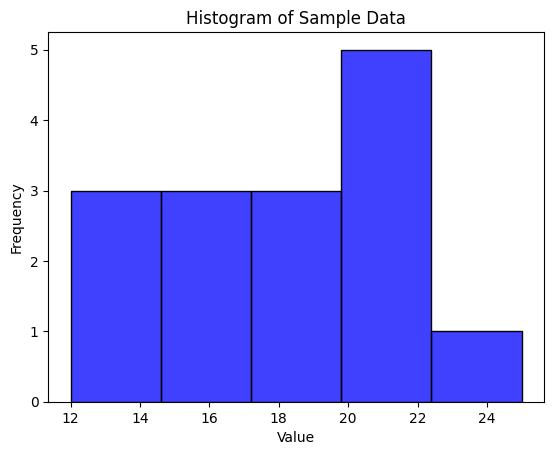

In [16]:
# Import necessary libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data
data = [12, 15, 12, 18, 20, 18, 15, 22, 25, 20, 18, 12, 15, 22, 20]

# Create a histogram
sns.histplot(data, bins=5, kde=False, color='blue')

# Add labels and title
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Sample Data")

# Show the plot
plt.show()


**Question 9: Use a Panda to load a CSA file and display its first 5 rows.**

- In Python, the Pandas library is used to work with tabular data. You can use the read_csv() function to load a CSV file into a DataFrame. A DataFrame is like a table in Python where you can perform data analysis easily. After loading the data, the head() function is used to display the first few rows of the DataFrame.

In [21]:
# Import pandas library
import pandas as pd

# Read the text file line by line and remove newline characters
with open("destination.txt", "r") as file:
    lines = [line.strip() for line in file.readlines()]  # Strip removes \n

# Convert the lines into a DataFrame
data = pd.DataFrame(lines, columns=["Text"])

# Display the first 5 rows
print(data.head())


                         Text
0  This is my sample content.
1        Copied successfully!


**Question 10: Calculate the correlation matrix using Seaborn and visualize it with a heatmap.**

- A correlation matrix shows the relationship between different numerical variables in a dataset. Values range from -1 to 1, where:
1 means perfect positive correlation,
-1 means perfect negative correlation, and
0 means no correlation.
Using Seaborn, you can visualize the correlation matrix with a heatmap, which makes it easier to understand patterns in the data.

               Math   Physics  Chemistry   Biology
Math       1.000000  0.985038   0.947212  0.757329
Physics    0.985038  1.000000   0.984339  0.685900
Chemistry  0.947212  0.984339   1.000000  0.589502
Biology    0.757329  0.685900   0.589502  1.000000


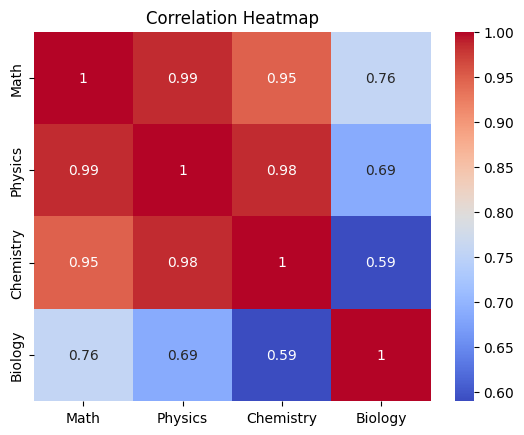

In [22]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample dataset
data = pd.DataFrame({
    'Math': [90, 80, 70, 85, 95],
    'Physics': [85, 78, 75, 82, 88],
    'Chemistry': [88, 74, 72, 80, 92],
    'Biology': [75, 80, 70, 78, 85]
})

# Calculate the correlation matrix
correlation_matrix = data.corr()

# Display the correlation matrix
print(correlation_matrix)

# Visualize the correlation matrix with a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
